# VQE on Real IBM Quantum Hardware

**Thomas Griffiths** — Quantum Computing Course (PH10110), University of Edinburgh

This notebook runs the actual VQE ground-state search on real IBM Quantum
hardware (`ibm_fez`), at the 12-qubit, RealAmplitudes/COBYLA configuration
identified as the best trade-off of accuracy and circuit depth by the
`Regression.ipynb` extrapolation. Real device time is limited (the free tier
gives ~10 minutes), so each run targets a single $J_z$ value with a short
optimizer budget (35 COBYLA iterations) and a physically-motivated **warm
start**: the initial circuit state is prepared as the Néel
(antiferromagnetic), ferromagnetic, or uniform-superposition state depending
on which phase $J_z$ falls into, giving the optimizer a head start near the
expected ground state.

## Workflow
This notebook is run **once per $J_z$ value** rather than in one pass:

1. Set `Jz` near the top of the first cell to the desired value.
2. Run cells 0–4 to connect to IBM hardware, build the warm-started ansatz,
   run VQE, compute $S(\pi)$, and save the result to
   `vqe_IBM_Jz{Jz}_n{n_qubits}.npy`.
3. Repeat for each $J_z$ value of interest (this project used
   $J_z \in \{-3, -2, -1, 0, 1, 2, 3\}$).
4. Once all `.npy` files exist, run cells 5–7 to load every saved run, compute
   matching noiseless/noisy classical comparisons at the same warm-started
   configuration, and produce the final comparison plots (energy and
   $S(\pi)$ vs. $J_z$, IBM hardware vs. noiseless simulation vs. noisy
   simulation vs. exact diagonalization).

All outputs (`.npy` run data and plots) are saved to the shared `Results/`
directory used across this project. The repository already includes the
seven completed runs ($J_z \in \{-3,...,3\}$) used in the final report, so
cells 5–7 (loading and plotting) can be run directly without repeating the
hardware runs in cells 0–4.

## Requirements
A `token.json` file (`{"api_key": "..."}`) with a valid IBM Quantum API key,
plus `qiskit`, `qiskit-aer`, `qiskit-ibm-runtime`, `qiskit-algorithms`.

## Known limitation
Cells 0–4 (the actual hardware run) overwrite `Jz`/`n_qubits` each time they're
rerun for a new value — there's no loop, so getting all seven runs means
manually re-editing and re-executing the first half of the notebook seven
times. This is intentional given hardware time constraints (each run is
manually budgeted), but means the notebook can't be run start-to-finish in
one pass the way the others can; cells 5–7 are the only part safe to "run
all".

In [58]:
import numpy as np
import json
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2, real_amplitudes
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_algorithms.optimizers import COBYLA
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import Batch
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel

In [49]:
# ----- Connect to IBM ----- #

with open("token.json", "r") as f:
    token = json.load(f)

QiskitRuntimeService.save_account(
    channel='ibm_quantum_platform',
    instance='open-instance',
    token=token["api_key"],
    overwrite=True,
    set_as_default=True
)
service = QiskitRuntimeService(channel='ibm_quantum_platform')
#backend = service.backend("ibm_marrakesh")
backend = service.backend("ibm_fez")
print(f"Using backend: {backend.name}")

# ----- Hamiltonian ----- #

n_qubits    = 12
Jz          = 3
coupling_map = [[i, i+1] for i in range(n_qubits - 1)]

def heisenberg_hamiltonian(n_qubits, Jz=1.0):
    terms = []
    for i in range(n_qubits - 1):
        xx = ["I"] * n_qubits; xx[i] = "X"; xx[i+1] = "X"
        terms.append(("".join(xx), 1.0))

        yy = ["I"] * n_qubits; yy[i] = "Y"; yy[i+1] = "Y"
        terms.append(("".join(yy), 1.0))

        zz = ["I"] * n_qubits; zz[i] = "Z"; zz[i+1] = "Z"
        terms.append(("".join(zz), float(Jz)))

    return SparsePauliOp.from_list(terms)

H = heisenberg_hamiltonian(n_qubits, Jz)

# ----- Antiparallel Warm Start ----- #

# The Néel state |↑↓↑↓...⟩ is a good initial guess for the ground state
# of the Heisenberg chain — it's the classical antiferromagnetic configuration.
# We prepend X gates on alternating qubits to prepare this state before
# the ansatz layers, giving the optimizer a head start near the true ground state.

initial_state = QuantumCircuit(n_qubits)

if Jz < -1:
    # Ferromagnetic: all spins up |111...1⟩ or all spins down |000...0⟩ 
    for i in range(n_qubits):
        initial_state.x(i)  # all spins up |↑↑↑↑...⟩

elif Jz > 1:
    # Antiferromagnetic: |↑↓↑↓...⟩
    for i in range(0, n_qubits, 2):
        initial_state.x(i)

else:
    # XY phase: uniform superposition — H gates on all qubits
    for i in range(n_qubits):
        initial_state.h(i)

# ----- Ansatz & Transpile ----- #

base_ansatz = real_amplitudes(
    n_qubits,
    reps=1,
    entanglement='linear',
).decompose()

# Compose the initial state with the ansatz
ansatz = initial_state.compose(base_ansatz).decompose()

# Transpile the ansatz for the target backend to get an accurate depth estimate.
pm          = generate_preset_pass_manager(target=backend.target, optimization_level=3)
isa_circuit = pm.run(ansatz)

print(f"Ansatz parameters : {ansatz.num_parameters}")
print(f"Transpiled depth  : {isa_circuit.depth()}")

Using backend: ibm_fez
Ansatz parameters : 24
Transpiled depth  : 53


In [50]:
# ----- Storing Intermediate Results ----- #

counts, values = [], []

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)
    print(f"  Iter {eval_count:3d}: E = {mean:.6f}")

# ----- VQE on IBM Hardware ----- #

estimator = Estimator(mode=backend)
optimizer = COBYLA(maxiter=35) 

vqe = VQE(estimator, isa_circuit, optimizer, callback=store_intermediate_result)
result = vqe.compute_minimum_eigenvalue(H)

print(f"\nGround state energy (Jz={Jz}): {result.eigenvalue:.6f}")

  Iter   1: E = 1.786568
  Iter   2: E = 3.086274
  Iter   3: E = 2.293085
  Iter   4: E = 0.673935
  Iter   5: E = 1.715849
  Iter   6: E = -0.613936
  Iter   7: E = 0.273218
  Iter   8: E = -3.345838
  Iter   9: E = -1.255350
  Iter  10: E = -4.364718
  Iter  11: E = -2.778366
  Iter  12: E = -5.382723
  Iter  13: E = -5.326425
  Iter  14: E = -7.341083
  Iter  15: E = -5.958607
  Iter  16: E = -5.805897
  Iter  17: E = -3.120499
  Iter  18: E = -8.160397
  Iter  19: E = -6.208990
  Iter  20: E = -7.253317
  Iter  21: E = -5.502902
  Iter  22: E = -7.576351
  Iter  23: E = -11.815109
  Iter  24: E = -9.354245
  Iter  25: E = -9.926723
  Iter  26: E = -17.090601
  Iter  27: E = -16.563263
  Iter  28: E = -16.949275
  Iter  29: E = -17.377936
  Iter  30: E = -16.896926
  Iter  31: E = -17.238951
  Iter  32: E = -16.726872
  Iter  33: E = -14.064013
  Iter  34: E = -17.042288
  Iter  35: E = -19.809337

Ground state energy (Jz=3): -19.809337


In [51]:
# ----- S(π) Structure Factor ----- #

# S(π) measures the antiferromagnetic order of the ground state.
# Evaluated once after VQE using the optimal parameters found above.
# A large S(π) indicates antiferromagnetic ordering, small = ferromagnetic/XY.

def s_pi_operator(n):
    terms = []
    for i in range(n):
        for j in range(i+1, n):
            pauli    = ["I"] * n
            pauli[i] = "Z"
            pauli[j] = "Z"
            coeff    = ((-1) ** (i - j)) / n
            terms.append(("".join(pauli), coeff))
    return SparsePauliOp.from_list(terms)

s_pi       = s_pi_operator(n_qubits)
isa_s_pi   = s_pi.apply_layout(isa_circuit.layout)

spi_result = estimator.run([(isa_circuit, isa_s_pi, result.optimal_point)]).result()
spi_value  = float(spi_result[0].data.evs)

print(f"S(π) = {spi_value:.6f}")

np.save(f"vqe_IBM_Jz{Jz}_n{n_qubits}.npy", {
    "energy"      : result.eigenvalue,
    "params"      : result.optimal_point,
    "counts"      : counts,
    "values"      : values,
    "spi"         : spi_value
})

S(π) = 0.972882


Exact ground state energy (Jz=3): -37.294727


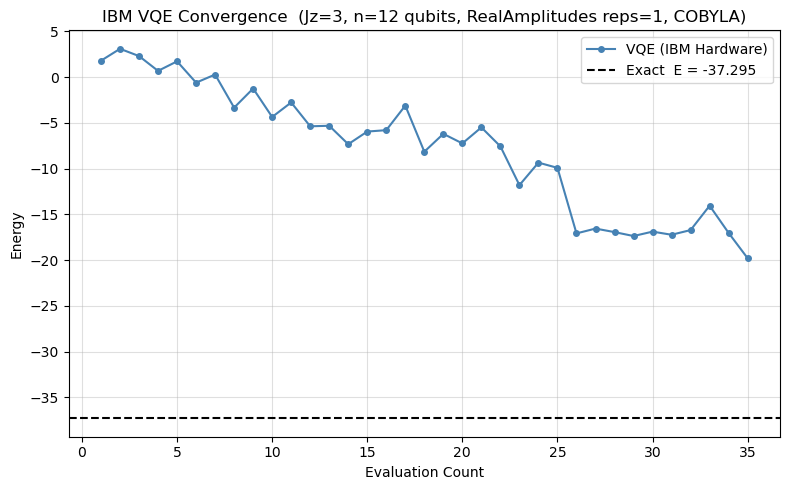

In [52]:
# ----- Exact Ground State Energy (classical benchmark) ----- #

# Get the exact ground state energy at this Jz value for comparison
H_matrix   = np.array(H.to_matrix())
exact_energy = np.linalg.eigvalsh(H_matrix)[0]
print(f"Exact ground state energy (Jz={Jz}): {exact_energy:.6f}")

# ----- Plot: Convergence ----- #

plt.figure(figsize=(8, 5))
plt.plot(counts, values, 'o-', color='steelblue', markersize=4, label='VQE (IBM Hardware)')
plt.axhline(exact_energy, color='black', linestyle='dashed', label=f'Exact  E = {exact_energy:.3f}')
plt.xlabel("Evaluation Count")
plt.ylabel("Energy")
plt.title(f"IBM VQE Convergence  (Jz={Jz}, n={n_qubits} qubits, RealAmplitudes reps=1, COBYLA)")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f"vqe_IBM_convergence_Jz{Jz}_n{n_qubits}.png", dpi=150)
plt.show()

In [53]:
# ----- Load IBM Data ----- #

Jz_runs = [-3, -2, -1, 0, 1, 2, 3]
n_qubits = 12
ibm_data = {}

for Jz_load in Jz_runs:
    try:
        d = np.load(f"vqe_IBM_Jz{Jz_load}_n{n_qubits}.npy", allow_pickle=True).item()
        ibm_data[Jz_load] = d
        print(f"Jz = {Jz_load}: Energy = {d['energy']:.6f}, S(π) = {d['spi']:.6f}")
    except FileNotFoundError:
        print(f"Data file for Jz={Jz_load} not found.")

Jz = -3: Energy = -21.506225, S(π) = 0.423450
Jz = -2: Energy = -8.476959, S(π) = -0.139420
Jz = -1: Energy = -6.013257, S(π) = -0.285195
Jz = 0: Energy = -6.968105, S(π) = 0.138546
Jz = 1: Energy = -8.613943, S(π) = 0.234100
Jz = 2: Energy = -10.180786, S(π) = 0.185294
Jz = 3: Energy = -19.809337, S(π) = 0.972882


In [59]:
# ----- Classical Comparison VQEs ----- #

ansatz_classical = real_amplitudes(n_qubits, reps = 1, entanglement='linear').decompose()
optimizer_class = COBYLA(maxiter=35)

noiseless_estimator = StatevectorEstimator()

coupling_map_class = [[i, i+1] for i in range(n_qubits - 1)]
device = GenericBackendV2(num_qubits=n_qubits, coupling_map=coupling_map_class, seed = 64)
noise_model = NoiseModel.from_backend(device)

noisy_estimator = AerEstimator(
    options = {
        "default_precision": 1e-2,
        "backend_options": {
            "method": "density_matrix",
            "coupling_map": coupling_map_class,
            "noise_model": noise_model,
        }
    }
)

vqe_noiseless = VQE(noiseless_estimator, ansatz_classical, optimizer_class)
vqe_noisy     = VQE(noisy_estimator, ansatz_classical, optimizer_class)

j_comp = Jz_runs
E_noiseless = []
E_noisy     = []
E_exact = []
Spi_noiseless = []
Spi_noisy     = []
Spi_exact = []

opt_params_noiseless = None
opt_params_noisy     = None

for Jz_val in j_comp:
    print(f"\n── Jz = {Jz_val} ──")
    H_comp = heisenberg_hamiltonian(n_qubits, Jz_val)

    # Exact diagonalisation
    H_matrix     = np.array(H_comp.to_matrix())
    evals, evecs = np.linalg.eigh(H_matrix)
    E_exact.append(evals[0])
    s_pi_mat     = np.array(s_pi_operator(n_qubits).to_matrix())
    Spi_exact.append(float(np.real(evecs[:, 0].conj() @ s_pi_mat @ evecs[:, 0])))

    # Warm start
    initial_state_comp = QuantumCircuit(n_qubits)
    if Jz_val < -1:
        for i in range(n_qubits): initial_state_comp.x(i)
    elif Jz_val > 1:
        for i in range(0, n_qubits, 2): initial_state_comp.x(i)
    else:
        for i in range(n_qubits): initial_state_comp.h(i)

    ansatz_ws = initial_state_comp.compose(
        real_amplitudes(n_qubits, reps=1, entanglement='linear')
    ).decompose()

    vqe_noiseless.ansatz = ansatz_ws
    vqe_noisy.ansatz     = ansatz_ws

    if opt_params_noiseless is not None:
        vqe_noiseless.initial_point = opt_params_noiseless
    if opt_params_noisy is not None:
        vqe_noisy.initial_point = opt_params_noisy

    # Noiseless
    res_nl = vqe_noiseless.compute_minimum_eigenvalue(H_comp)
    E_noiseless.append(float(np.real(res_nl.eigenvalue)))
    opt_params_noiseless = res_nl.optimal_point
    spi_nl = noiseless_estimator.run(
        [(ansatz_ws, s_pi_operator(n_qubits), opt_params_noiseless)]
    ).result()
    Spi_noiseless.append(float(np.real(spi_nl[0].data.evs)))
    print(f"  Noiseless: E={E_noiseless[-1]:.4f}  S(π)={Spi_noiseless[-1]:.4f}")

    # Noisy
    res_ny = vqe_noisy.compute_minimum_eigenvalue(H_comp)
    E_noisy.append(float(np.real(res_ny.eigenvalue)))
    opt_params_noisy = res_ny.optimal_point
    spi_ny = noisy_estimator.run(
        [(ansatz_ws, s_pi_operator(n_qubits), opt_params_noisy)]
    ).result()
    Spi_noisy.append(float(np.real(spi_ny[0].data.evs)))
    print(f"  Noisy    : E={E_noisy[-1]:.4f}  S(π)={Spi_noisy[-1]:.4f}")


── Jz = -3 ──
  Noiseless: E=-21.1182  S(π)=-0.3263
  Noisy    : E=-21.1324  S(π)=-0.3805

── Jz = -2 ──
  Noiseless: E=-17.2960  S(π)=-0.4051
  Noisy    : E=-16.1537  S(π)=-0.4128

── Jz = -1 ──
  Noiseless: E=-8.6379  S(π)=-0.3586
  Noisy    : E=-8.7134  S(π)=-0.3182

── Jz = 0 ──
  Noiseless: E=-9.9185  S(π)=0.1995
  Noisy    : E=-7.7676  S(π)=0.2176

── Jz = 1 ──
  Noiseless: E=-14.8512  S(π)=0.8629
  Noisy    : E=-13.9232  S(π)=0.7995

── Jz = 2 ──
  Noiseless: E=-11.0746  S(π)=0.2703
  Noisy    : E=-13.7948  S(π)=0.1216

── Jz = 3 ──
  Noiseless: E=-22.5230  S(π)=0.3107
  Noisy    : E=-23.5255  S(π)=0.4739


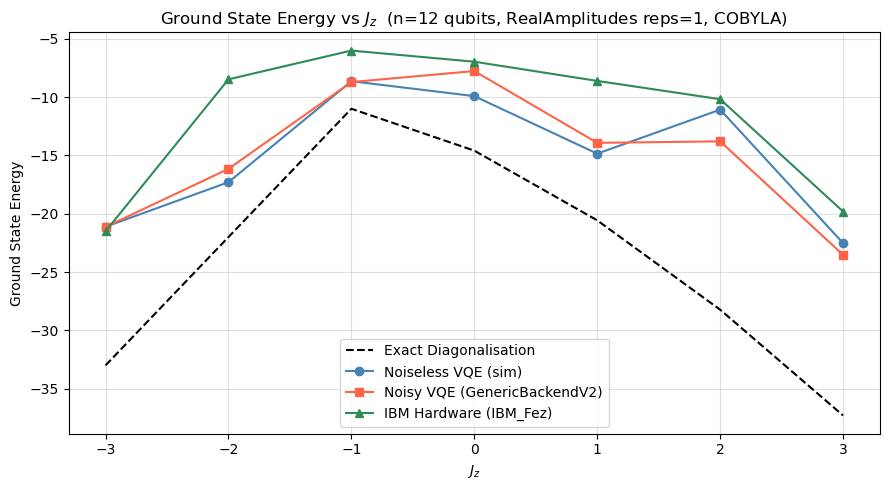

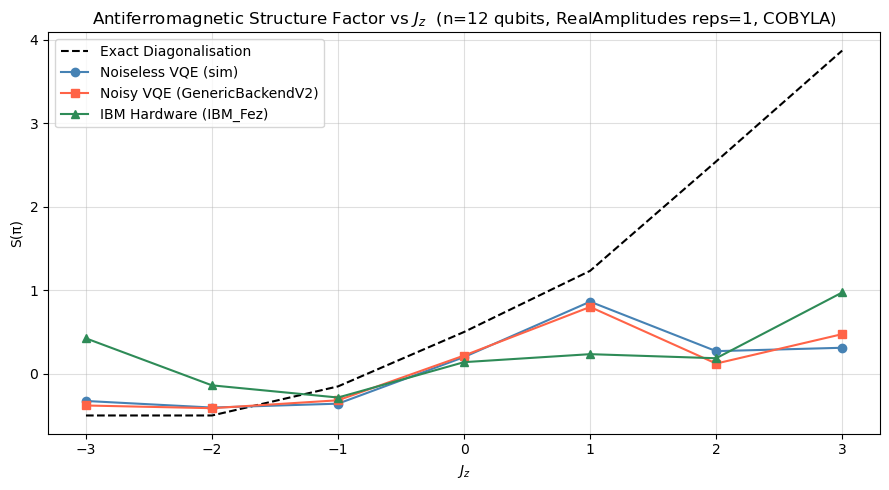

In [61]:
# ----- Compile IBM results ----- #

Jz_ibm  = sorted(ibm_data.keys())
E_ibm   = [ibm_data[j]["energy"] for j in Jz_ibm]
Spi_ibm = [ibm_data[j]["spi"]    for j in Jz_ibm]

# ----- Plot 1: Ground State Energy vs Jz ----- #

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(j_comp,  E_exact,     'k--',  label='Exact Diagonalisation')
ax.plot(j_comp,  E_noiseless, 'o-',   color='steelblue',  label='Noiseless VQE (sim)')
ax.plot(j_comp,  E_noisy,     's-',   color='tomato',     label='Noisy VQE (GenericBackendV2)')
ax.plot(Jz_ibm,  E_ibm,       '^-',   color='seagreen',   label='IBM Hardware (IBM_Fez)')

ax.set_xlabel("$J_z$")
ax.set_ylabel("Ground State Energy")
ax.set_title(f"Ground State Energy vs $J_z$  (n={n_qubits} qubits, RealAmplitudes reps=1, COBYLA)")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_energy_n{n_qubits}.png", dpi=150)
plt.show()

# ----- Plot 2: Structure Factor vs Jz ----- #

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(j_comp,  Spi_exact,     'k--',  label='Exact Diagonalisation')
ax.plot(j_comp,  Spi_noiseless, 'o-',   color='steelblue',  label='Noiseless VQE (sim)')
ax.plot(j_comp,  Spi_noisy,     's-',   color='tomato',     label='Noisy VQE (GenericBackendV2)')
ax.plot(Jz_ibm,  Spi_ibm,       '^-',   color='seagreen',   label='IBM Hardware (IBM_Fez)')

ax.set_xlabel("$J_z$")
ax.set_ylabel("S(π)")
ax.set_title(f"Antiferromagnetic Structure Factor vs $J_z$  (n={n_qubits} qubits, RealAmplitudes reps=1, COBYLA)")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_spi_n{n_qubits}.png", dpi=150)
plt.show()